# Асимптотика VI и PI

Для разных размеров сетки (2×2, 3×3, …) генерируем карту, по Дейкстре находим минимальный урон, задаём hp = damage + 1, запускаем VI и PI с фиксированным θ и замеряем время. В конце — один график: размер сетки vs время (VI и PI).

In [1]:
import sys
from pathlib import Path

import numpy as np

root = Path.cwd().parent if Path.cwd().name == "experiments" else Path.cwd()
sys.path.insert(0, str(root))

from src.environment import ParkourEnv
from src.algorithms import ValueIteration, PolicyIteration
from src.landscape import generate_height_map, build_graph, dijkstra

/Users/vasilij/Documents/RL_proj3/Parkour/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Гиперпараметры

- **theta** — общий критерий сходимости для VI и PI (и для внутренней оценки в PI).
- Параметры ландшафта и Дейкстры совпадают с правилами окружения (max_jump_up, safe_jump_down).

In [ ]:
THETA = 0.2
GAMMA = 0.99
MAX_JUMP_UP = 3
SAFE_JUMP_DOWN = 1
MIN_HEIGHT, MAX_HEIGHT = 1, 10
SEED_BASE = 42
MAX_GRID_SIZE = 100  # 2, 3, ..., 8 — можно увеличить
N_MAPS = 1  # сколько карт на каждый размер сетки для усреднения времени

## Цикл по размерам сетки

Для каждого размера: генерируем карту, строим граф, Дейкстра → минимальный урон; hp_start = damage + 1. Создаём окружение (inline config), запускаем VI и PI с одним theta, сохраняем время.

In [3]:
rewards = {"victory": 100, "death": -100, "step": -1}
algo_config_vi = {"gamma": GAMMA, "theta": THETA, "max_iters": 50000}
algo_config_pi = {"gamma": GAMMA, "theta": THETA, "max_eval_iters": 5000}

results = []  # list of {grid_size, n_states, min_damage, hp_start, time_vi, time_pi}

In [4]:
for grid_size in range(2, MAX_GRID_SIZE + 1):
    start = (0, 0)
    end = (grid_size - 1, grid_size - 1)
    times_vi, times_pi = [], []

    for map_idx in range(N_MAPS):
        attempt = 0
        while True:
            seed = SEED_BASE + grid_size * 10000 + map_idx * 1000 + attempt
            height_map = generate_height_map(grid_size, MIN_HEIGHT, MAX_HEIGHT, seed)
            graph = build_graph(height_map, MAX_JUMP_UP, SAFE_JUMP_DOWN)
            total_damage, path = dijkstra(graph, start, end)
            if path is not None and total_damage != float("inf"):
                break
            attempt += 1

        hp_start = int(total_damage) + 1
        env_config = {
            "height_map": height_map.tolist(),
            "hp_start": hp_start,
            "rewards": rewards,
            "max_jump_up": MAX_JUMP_UP,
            "safe_jump_down": SAFE_JUMP_DOWN,
        }

        env = ParkourEnv(env_config)
        n_states = env.rows * env.cols * (env.hp_start + 1)

        algo_vi = ValueIteration(env, algo_config_vi)
        info_vi = algo_vi.solve()
        times_vi.append(info_vi["time"])

        env2 = ParkourEnv(env_config)
        algo_pi = PolicyIteration(env2, algo_config_pi)
        info_pi = algo_pi.solve()
        times_pi.append(info_pi["time"])

    time_vi_mean = np.mean(times_vi)
    time_pi_mean = np.mean(times_pi)
    time_vi_std = np.std(times_vi)
    time_pi_std = np.std(times_pi)

    results.append({
        "grid_size": grid_size,
        "n_states": n_states,
        "min_damage": total_damage,
        "hp_start": hp_start,
        "time_vi": time_vi_mean,
        "time_pi": time_pi_mean,
        "time_vi_std": time_vi_std,
        "time_pi_std": time_pi_std,
    })
    print(f"Grid {grid_size}x{grid_size}: {N_MAPS} maps, time_vi={time_vi_mean:.4f}s ± {time_vi_std:.4f}, time_pi={time_pi_mean:.4f}s ± {time_pi_std:.4f}")

  1%|          | 619/50000 [00:00<00:01, 33938.22it/s]


Grid 2x2: 5 maps, time_vi=0.0384s ± 0.0278, time_pi=0.0153s ± 0.0111


  1%|          | 619/50000 [00:00<00:00, 67805.54it/s]


Grid 3x3: 5 maps, time_vi=0.0135s ± 0.0014, time_pi=0.0131s ± 0.0045


  1%|          | 619/50000 [00:00<00:00, 97538.29it/s]


...

Grid 32x32: 5 maps, time_vi=0.2618s ± 0.0367, time_pi=0.4834s ± 0.5858


  1%|          | 619/50000 [00:00<00:21, 2258.97it/s]


Grid 33x33: 5 maps, time_vi=0.3223s ± 0.0604, time_pi=1.0315s ± 0.6927


  1%|          | 619/50000 [00:00<00:17, 2813.02it/s]


KeyboardInterrupt: 

## Один график: размер сетки vs время (VI и PI)

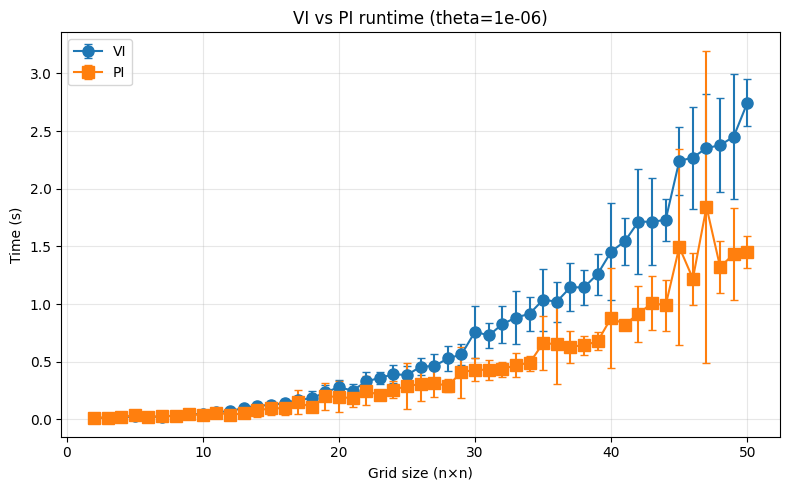

In [ ]:
import json
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt

if not results:
    print("No results to plot.")
else:
    grid_sizes = [r["grid_size"] for r in results]
    time_vi = [r["time_vi"] for r in results]
    time_pi = [r["time_pi"] for r in results]
    time_vi_std = [r.get("time_vi_std", 0) for r in results]
    time_pi_std = [r.get("time_pi_std", 0) for r in results]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(grid_sizes, time_vi, yerr=time_vi_std, fmt="o-", label="VI", markersize=8, capsize=3)
    ax.errorbar(grid_sizes, time_pi, yerr=time_pi_std, fmt="s-", label="PI", markersize=8, capsize=3)
    ax.set_xlabel("Grid size (n×n)")
    ax.set_ylabel("Time (s)")
    ax.set_title(f"VI vs PI runtime (theta={THETA})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Сохранение результатов
    results_dir = Path.cwd() if Path.cwd().name == "experiments" else Path.cwd() / "experiments"
    results_dir.mkdir(parents=True, exist_ok=True)
    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    out_path = results_dir / f"results_asymptotics_vi_pi_{timestamp}.json"
    serializable = []
    for r in results:
        serializable.append({
            "grid_size": int(r["grid_size"]),
            "n_states": int(r["n_states"]),
            "min_damage": float(r["min_damage"]),
            "hp_start": int(r["hp_start"]),
            "time_vi": float(r["time_vi"]),
            "time_pi": float(r["time_pi"]),
            "time_vi_std": float(r.get("time_vi_std", 0)),
            "time_pi_std": float(r.get("time_pi_std", 0)),
        })
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump({"theta": THETA, "gamma": GAMMA, "n_maps": N_MAPS, "results": serializable}, f, indent=2)
    print(f"Результаты сохранены: {out_path}")